In [1]:
# pyrefly: ignore [missing-import]
import langgraph
# pyrefly: ignore [missing-import]
from langgraph.graph import MessagesState

In [2]:
from typing import List

class State(MessagesState):
    """State class for the LangGraph workflow. It keeps track of the information necessary to maintain a coherent
    conversation between the Philosopher and the user.

    Attributes:
        philosopher_context (str): The historical and philosophical context of the philosopher.
        philosopher_name (str): The name of the philosopher.
        philosopher_perspective (str): The perspective of the philosopher about AI.
        philosopher_style (str): The style of the philosopher.
        summary (str): A summary of the conversation. This is used to reduce the token usage of the model.
    """

    context: str
    query : str
    retrived_docs: str
    retrived_images: List[str]
    final_relevant_docs: str
    summary: str

# Config

In [3]:
from dataclasses import dataclass

@dataclass
class qdrant:
    PORT = 6333
    HOST = "localhost"
    IMAGE_COLLECTION_NAME = "research_paper_rag_hybrid_v6"
    TEXT_COLLECTION_NAME = "research_paper_rag_text_v5"
    FUSION_METHOD= "Weigthed_Fusion"
    ALPHA_VALUE = 0.4

@dataclass
class vlm_model:
    VLM_MODEl = "nvidia/llama-3.1-nemotron-nano-vl-8b-v1"

@dataclass
class embedding_model:
    dense_text_model = "mixedbread-ai/mxbai-embed-large-v1"
    sparse_text_model = "Qdrant/bm25"
    image_model = "google/siglip-base-patch16-512"

## Utils 

### Compute weighted fusion

In [ ]:
def compute_weighted_fusion(dense_list, sparse_list, alpha=0.4):
    """
    Computes Weighted Fusion across two lists of Qdrant points.
    Alpha controls the weight of the dense_list, and (1-alpha) controls sparse_list.
    Returns a single sorted list of points.
    """
    dense_scores = {p.id: p.score for p in dense_list}
    sparse_scores = {p.id: p.score for p in sparse_list}
    
    # Normalize scores (Min-Max scaling)
    def normalize(scores):
        if not scores:
            return scores
        min_val = min(scores.values())
        max_val = max(scores.values())
        if max_val == min_val:
            return {k: 1.0 for k in scores}
        return {k: (v - min_val) / (max_val - min_val) for k, v in scores.items()}
    norm_dense = normalize(dense_scores)
    norm_sparse = normalize(sparse_scores)
    
    fused_scores = {}
    point_map = {}
    
    for p in dense_list:
        point_map[p.id] = p
        fused_scores[p.id] = alpha * norm_dense.get(p.id, 0)
        
    for p in sparse_list:
        point_map[p.id] = p
        if p.id in fused_scores:
            fused_scores[p.id] += (1 - alpha) * norm_sparse.get(p.id, 0)
        else:
            fused_scores[p.id] = (1 - alpha) * norm_sparse.get(p.id, 0)
            
    # Sort by fused score descending
    sorted_ids = sorted(fused_scores.keys(), key=lambda x: fused_scores[x], reverse=True)
    return [point_map[pid] for pid in sorted_ids]
     

### Sglip

In [ ]:
import torch
from PIL import Image
from transformers import AutoProcessor, AutoModel

class SiglipEmbedder:
    def __init__(self, model_name="google/siglip-base-patch16-512", device="cpu"):
        print(f"Loading {model_name}...")
        self.processor = AutoProcessor.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name).to(device)
        self.device = device
        
    def encode(self, text):
        """Encodes text into a normalized SigLIP vector."""
        if isinstance(text, str):
            text = [text]
            
        inputs = self.processor(text=text, padding="max_length", return_tensors="pt").to(self.device)
        with torch.no_grad():
            text_features = self.model.get_text_features(**inputs)
            # SigLIP requires manual L2 normalization for cosine similarity
            text_features = text_features / text_features.norm(p=2, dim=-1, keepdim=True)
            
        if len(text) == 1:
            return text_features[0].cpu().numpy()
        return text_features.cpu().numpy()

    def encode_image(self, image):
        """Helper function if you need to re-index your images into Qdrant."""
        # If a file path is provided as a string, open it with PIL
        if isinstance(image, str):
            image = Image.open(image).convert("RGB")
            
        inputs = self.processor(images=image, return_tensors="pt").to(self.device)
        with torch.no_grad():
            image_features = self.model.get_image_features(**inputs)
            image_features = image_features / image_features.norm(p=2, dim=-1, keepdim=True)
            
        return image_features[0].cpu().numpy()


# Basic Workflow of the LangGraph 

- query arrrievs added to messages
- Start to need_extraction
- if extraction is needed then add the go to retrive docs and retrive images otherwise go to generation and end
- Then see if the retrived docs are relevant to the quetion 
- If one of the doc is relevant, it with that part
- other wise give the ans no relevant docs are found 
- add the ans also to the nessageds and end it 

# Load Libraries

In [88]:
import os
import operator
from dataclasses import dataclass
from typing import TypedDict, Annotated, List, Dict, Any

from qdrant_client import QdrantClient, models
from sentence_transformers import SentenceTransformer
from fastembed import SparseTextEmbedding
from langgraph.graph import StateGraph, START, END

# Import ChatNVIDIA instead of ChatOllama
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langgraph.checkpoint.sqlite import SqliteSaver
from langchain_core.prompts import PromptTemplate

# Optional: if you need to load .env manually at runtime
from dotenv import load_dotenv
load_dotenv()

True

## CONFIGURATIONS

In [71]:

# ==========================================
# 1. CONFIGURATIONS
# ==========================================

@dataclass
class qdrant:
    PORT = 6333
    HOST = "localhost"
    IMAGE_COLLECTION_NAME = "research_paper_image_v6"
    TEXT_COLLECTION_NAME = "research_papers_text_v5"
    FUSION_METHOD = "Weigthed_Fusion"
    ALPHA_VALUE = 0.4  # Dense Weight (Sparse gets 1 - 0.4 = 0.6)

@dataclass
class vlm_model:
    VLM_MODEl = "nvidia/llama-3.1-nemotron-nano-vl-8b-v1"

@dataclass
class embedding_model:
    dense_text_model = "mixedbread-ai/mxbai-embed-large-v1"
    sparse_text_model = "Qdrant/bm25"
    image_model = "google/siglip-base-patch16-512"

@dataclass
class small_llm_config:
    MODEL_NAME = "meta/llama-3.2-3b-instruct"# Standard Nvidia NIM name for Llama 3 8B, adjust if using 3.1

# Initialize ChatNVIDIA LLMs
# It will automatically detect NVIDIA_API_KEY from your environment variables


## Loading Models

In [72]:
if "NVIDIA_API_KEY" not in os.environ:
    raise ValueError("⚠️ NVIDIA_API_KEY not found in .env file!")

# vision_llm = ChatNVIDIA(model="nvidia/llama-3.1-nemotron-nano-vl-8b-v1")

small_llm = ChatNVIDIA(model=small_llm_config.MODEL_NAME, temperature=0.0)
vlm = ChatNVIDIA(model=vlm_model.VLM_MODEl, temperature=0.0)
print("configured Chat Nvidea models.")
# Initialize Qdrant and Embedding Models globally to avoid reloading them on every graph execution
qdrant_client = QdrantClient(host=qdrant.HOST, port=qdrant.PORT)
print("qdrant connection successfull.")
dense_model = SentenceTransformer(embedding_model.dense_text_model, device="cpu")
print("dense model loading successfull.")
bm25_model = SparseTextEmbedding(model_name=embedding_model.sparse_text_model)
print("sparse model loading successfull.")

configured Chat Nvidea models.
qdrant connection successfull.
dense model loading successfull.
sparse model loading successfull.


## prompts

In [73]:


# ==========================================
# 2. PROMPTS
# ==========================================

EXTRACTION_PROMPT = PromptTemplate.from_template(
    """You are an intelligent routing assistant. 
Your task is to determine whether the following user query requires searching an external knowledge base for specific factual information, research papers, or deep context.

If the query requires factual data, research papers, or specific knowledge, respond with exactly "Yes".
If the query is a simple greeting, general conversation, or something you can answer without external facts, respond with exactly "No".

User Query: {query}
Answer (Yes/No):"""
)

RELEVANCE_PROMPT = PromptTemplate.from_template(
    """You are a strict evaluator. Your task is to determine if the retrieved document contains relevant information to answer the user query.
Ignore formatting, but focus on the semantic meaning. 

If the document contains useful information to help answer the query, respond with exactly "Yes".
If the document is completely irrelevant or off-topic, respond with exactly "No".

Query: {query}

Document Context: 
{document_content}

Answer (Yes/No):"""
)

SUMMARY_PROMPT = PromptTemplate.from_template(
    """You are a helpful summarization assistant. 
Please summarize the following context concisely, extracting the core concepts, entities, and facts. Keep it under 250 words.

Context:
{context}

Summary:"""
)

GENERATE_WITH_CONTEXT_PROMPT = PromptTemplate.from_template(
    """You are an expert research assistant. Answer the user's question based strictly on the provided context below.
If the context does not contain enough information to answer the question, state that you do not have enough information.

Context:
{context}

Question: {query}
Answer:"""
)

GENERATE_DIRECT_PROMPT = PromptTemplate.from_template(
    """You are a helpful and intelligent assistant. Please answer the user's question directly and concisely.

Question: {query}
Answer:"""
)

## State

In [74]:

# ==========================================
# 3. STATE DEFINITION
# ==========================================

class GraphState(TypedDict):
    messages: Annotated[list, operator.add]
    query: str
    extraction_needed: str
    retrieved_docs: List[Dict[str, Any]]
    relevant_docs: List[Dict[str, Any]]

## Nodes

In [ ]:
# ==========================================
# 4. NODES
# ==========================================

def need_extraction(state: GraphState):
    """
    Decide if we need to retrieve documents. Returns "Yes" or "No" using small_llm.
    """
    print("--- [LOG] Node 'need_extraction' started ---")
    
    query = state.get("query")
    prompt_value = EXTRACTION_PROMPT.format(query=query)
    
    # Real ChatNVIDIA LLM Call
    response = small_llm.invoke(prompt_value)
    content = response.content.strip().lower()
    
    extraction_needed = "Yes" if "yes" in content else "No"
    
    print(f"--- [LOG] Node 'need_extraction' finished. Decision: {extraction_needed} ---")
    return {"extraction_needed": extraction_needed}


def retrieve_docs(state: GraphState):
    """
    Retrieve text documents using Hybrid Search (Dense + Sparse) with Min-Max 
    Normalization and Weighted Fusion.
    """
    print("--- [LOG] Node 'retrieve_docs' started ---")
    
    query = state.get("query")
    
    # Generate vectors
    dense_query_vector = dense_model.encode(query)
    sparse_emb = list(bm25_model.embed([query]))[0]
    sparse_query_vector = models.SparseVector(
        indices=sparse_emb.indices.tolist(),
        values=sparse_emb.values.tolist()
    )
    
    # Query Qdrant
    dense_res = qdrant_client.query_points(
        collection_name=qdrant.TEXT_COLLECTION_NAME,
        query=dense_query_vector,
        using="dense",
        limit=10,
        with_payload=True
    ).points
    
    sparse_res = qdrant_client.query_points(
        collection_name=qdrant.TEXT_COLLECTION_NAME,
        query=sparse_query_vector,
        using="sparse",
        limit=10,
        with_payload=True
    ).points

    # Min-Max Normalization Helper
    def process_results(res):
        scores = [p.score for p in res]
        if not scores:
            return {}
        min_s, max_s = min(scores), max(scores)
        
        norm_dict = {}
        for p in res:
            doc_id = str(p.payload.get("section_id", p.id) if p.payload else p.id)
            norm = (p.score - min_s) / (max_s - min_s) if max_s > min_s else 1.0
            
            if doc_id not in norm_dict or norm > norm_dict[doc_id]["score"]:
                norm_dict[doc_id] = {"score": norm, "payload": p.payload}
        return norm_dict
    
    dense_norm = process_results(dense_res)
    sparse_norm = process_results(sparse_res)
    
    all_docs = set(dense_norm.keys()).union(set(sparse_norm.keys()))
    
    # Apply Weighted Fusion
    w = qdrant.ALPHA_VALUE # Dense Weight = 0.4 (Sparse = 0.6)
    final_scores = []
    
    for doc in all_docs:
        d_data = dense_norm.get(doc, {"score": 0.0, "payload": None})
        s_data = sparse_norm.get(doc, {"score": 0.0, "payload": None})
        
        f_score = (w * d_data["score"]) + ((1 - w) * s_data["score"])
        payload = d_data["payload"] if d_data["payload"] else s_data["payload"]
        
        final_scores.append((f_score, payload))
        
    # Sort by final fused score (highest first)
    final_scores.sort(key=lambda x: x[0], reverse=True)
    
    # Get top 5 documents' payloads safely
    retrieved_docs = [payload for score, payload in final_scores[:5] if payload is not None]
    
    print(f"--- [LOG] Node 'retrieve_docs' finished. Found {len(retrieved_docs)} docs ---")
    return {"retrieved_docs": retrieved_docs}


def summary_nodes(state: GraphState):
    """
    If the context is bigger than a character threshold (e.g., 3000 chars), summarize it.
    """
    print("--- [LOG] Node 'summary_nodes' started ---")
    
    docs = state.get("retrieved_docs", [])
    if not docs:
        print("--- [LOG] Node 'summary_nodes' finished. No docs to summarize. ---")
        return {"retrieved_docs": docs}
        
    # Assuming text content is stored in the 'text' key inside your Qdrant payload
    full_context = "\n".join([doc.get("text", "") for doc in docs])
    
    if len(full_context) > 3000:
        print(f"--- [LOG] Node 'summary_nodes': Context is {len(full_context)} chars. Summarizing... ---")
        prompt_value = SUMMARY_PROMPT.format(context=full_context)
        response = small_llm.invoke(prompt_value)
        summarized_text = response.content.strip()
        
        # Overwrite list with single summarized document
        docs = [{"text": summarized_text, "source": "summarized_context"}]
    else:
        print(f"--- [LOG] Node 'summary_nodes': Context is {len(full_context)} chars (under 3000). Skipping summary. ---")
        
    print("--- [LOG] Node 'summary_nodes' finished ---")
    return {"retrieved_docs": docs}


def most_relevant(state: GraphState):
    """
    Use the small LLM to evaluate if retrieved docs are relevant to the query.
    """
    print("--- [LOG] Node 'most_relevant' started ---")
    
    query = state.get("query")
    docs = state.get("retrieved_docs", [])
    
    relevant = []
    for doc in docs:
        content = doc.get("text", "")
        if not content:
            continue
            
        prompt_value = RELEVANCE_PROMPT.format(query=query, document_content=content)
        response = small_llm.invoke(prompt_value)
        content_resp = response.content.strip().lower()
        
        if "yes" in content_resp:
            relevant.append(doc)
            
    print(f"--- [LOG] Node 'most_relevant' finished. Filtered down to {len(relevant)} relevant docs ---")
    return {"relevant_docs": relevant}


def no_relevant_docs_found(state: GraphState):
    """
    Appends a standard response when all retrieved docs are irrelevant.
    """
    print("--- [LOG] Node 'no_relevant_docs_found' started ---")
    
    ans = "No relevant docs are found in the database to answer your question."
    
    print("--- [LOG] Node 'no_relevant_docs_found' finished ---")
    return {"messages": [{"role": "assistant", "content": ans}]}


def generate_final_ans(state: GraphState):
    """
    Generates the final answer. If extraction wasn't needed, answers directly. 
    Otherwise, answers using the evaluated relevant context via the ChatNVIDIA VLM.
    """
    print("--- [LOG] Node 'generate_final_ans' started ---")
    
    relevant_docs = state.get("relevant_docs", [])
    extraction_needed = state.get("extraction_needed")
    query = state.get("query")
    
    if extraction_needed == "No":
        prompt_value = GENERATE_DIRECT_PROMPT.format(query=query)
        response = vlm.invoke(prompt_value)
        ans = response.content.strip()
    else:
        # Build context block
        context = "\n---\n".join([d.get("text", "") for d in relevant_docs])
        prompt_value = GENERATE_WITH_CONTEXT_PROMPT.format(context=context, query=query)
        response = vlm.invoke(prompt_value)
        ans = response.content.strip()
        
    print("--- [LOG] Node 'generate_final_ans' finished ---")
    return {"messages": [{"role": "assistant", "content": ans}]}


# ==========================================
# 5. ROUTERS (Conditional Edges)
# ==========================================

def route_after_extraction(state: GraphState):
    print("--- [LOG] Router 'route_after_extraction' evaluated ---")
    if state.get("extraction_needed") == "Yes":
        return "retrieve_docs"
    else:
        return "generate_final_ans"

def route_after_relevance(state: GraphState):
    print("--- [LOG] Router 'route_after_relevance' evaluated ---")
    if not state.get("relevant_docs"):
        return "no_relevant_docs_found"
    return "generate_final_ans"


##  GRAPH CONSTRUCTION

In [91]:
# ==========================================
# 6. GRAPH CONSTRUCTION
# ==========================================
workflow = StateGraph(GraphState)

# Add all nodes
workflow.add_node("need_extraction", need_extraction)
workflow.add_node("retrieve_docs", retrieve_docs)
workflow.add_node("most_relevant", most_relevant)
workflow.add_node("no_relevant_docs_found", no_relevant_docs_found)
workflow.add_node("generate_final_ans", generate_final_ans)

# Add entry point
workflow.add_edge(START, "need_extraction")

# Add edges and conditionals
workflow.add_conditional_edges(
    "need_extraction",
    route_after_extraction,
    {
        "retrieve_docs": "retrieve_docs",
        "generate_final_ans": "generate_final_ans"
    }
)

workflow.add_edge("retrieve_docs", "most_relevant")

workflow.add_conditional_edges(
    "most_relevant",
    route_after_relevance,
    {
        "no_relevant_docs_found": "no_relevant_docs_found",
        "generate_final_ans": "generate_final_ans"
    }
)

# Add exit points
workflow.add_edge("no_relevant_docs_found", END)
workflow.add_edge("generate_final_ans", END)

# === NEW: Add Memory Saver ===
import sqlite3
conn = sqlite3.connect("checkpoints.sqlite", check_same_thread=False)
memory = SqliteSaver(conn)

# Compile LangGraph app WITH the checkpointer



## Graph Compile

In [92]:
# Compile LangGraph app
app = workflow.compile(checkpointer=memory)

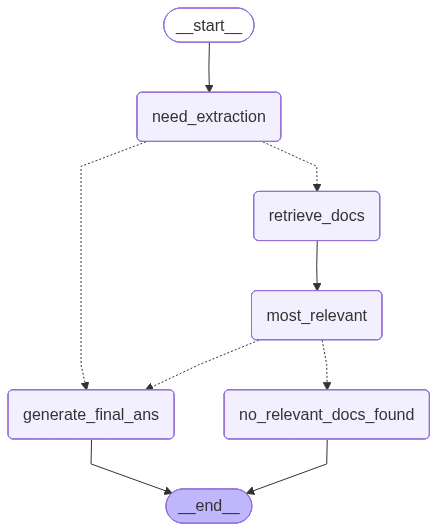

In [93]:
app

In [ ]:
# # 1. Define your initial input state
# initial_state = {
#     "query": "What are the latest advancements in quantum computing?",
#     "messages": [] # Starting with an empty message list
# }

# # Live stream the workflow steps
# for step in app.stream(initial_state):
#     for node_name, state_update in step.items():
#         print(f"--- Just completed node: {node_name} ---")
#         # You can print out the state updates here if you want to inspect them


--- Just completed node: need_extraction ---
--- Just completed node: retrieve_docs ---
--- Just completed node: most_relevant ---
--- Just completed node: no_relevant_docs_found ---


In [ ]:
# 0. Setup the config with a unique chat ID
config = {"configurable": {"thread_id": "chat_user_123"}}

# 1. Define your initial input state
initial_state = {
    "query": "How does the MLMM approach affect the analysis of Root Mean Squared Error (RMSE)?",
    "messages": [] # Starting with an empty message list
}

print("Starting workflow...")

# 2. Invoke the graph
# The graph will execute node by node and return the final state
final_state = app.invoke(initial_state, config=config)

print("\n--- WORKFLOW COMPLETED ---\n")

# 3. Print the final answer and logic path
print(f"Extraction Needed: {final_state.get('extraction_needed')}")
print(f"Total Relevant Docs Found: {len(final_state.get('relevant_docs', []))}")

print("\n--- FINAL ANSWER ---\n")
# The final generated answer is stored in the last message
if final_state.get("messages"):
    print(final_state["messages"][-1]["content"])
else:
    print("No messages were generated.")

Starting workflow...

--- WORKFLOW COMPLETED ---

Extraction Needed: Yes
Total Relevant Docs Found: 3

--- FINAL ANSWER ---

The MLMM approach allows for the direct modeling of the squared error, which is traditionally analyzed in an aggregation framework. In the context of RMSE, the MLMM approach extends Equation 6 to include a square root link function, enabling the analysis of the RMSE in a three-level metamodel structure. This approach provides several benefits, such as:

1. **Individual-level analysis**: The MLMM approach allows for the analysis of RMSE at the individual level, which can reveal insights that might be masked in an aggregation framework. For instance, the analysis of RMSE in the MLMM approach showed that covariate adjustment can provide substantial benefits for precision, increased power, and lower overall error, particularly when the correlation between the covariate and the outcome is strong.

2. **Interpretability**: The MLMM approach offers a succinct and interp

In [ ]:
len(final_state['retrieved_docs'])
len(final_state['relevant_docs'])

3

In [99]:
for i in final_state['relevant_docs']:
    print("new document\n\n")
    print(i['text'])

new document


Paper Title: Multilevel Metamodels: Enhancing Inference, Interpretability, and
  Generalizability in Monte Carlo Simulation Studies
Section Title: # 3.3 Squared Error

# 3.3 Squared Error 

We conclude with an analysis of the squared error to illustrate two additional affordances to the MLMM approach. First, even some model metrics that traditionally require aggregation can be analyzed in the three-level MLMM approach. Second, the MLMM is easily extended to non-linear contexts.

For example, consider the Root Mean Squared Error (RMSE), which combines the effects of bias and variance into a single metric, where $r$ indexes the simulation replication and $R$ is the total number of simulation replications:

$$
\operatorname{RMSE}=\sqrt{\frac{1}{R} \sum_{r=1}^{R}\left(\bar{\beta}_{1}^{(r)}-\beta_{1}\right)^{2}}
$$

The RMSE is traditionally analyzed in an aggregation framework because taking the mean requires averaging across a range of conditions. However, we can model the 

## Furtherimprovements
- Give the image to the LLM if itis in the section else not
- 

### Reson of not answering

- chunking 

In [ ]:
# 1. Define your initial input state
initial_state = {
    "query": "What are the latest advancements in quantum computing?",
    "messages": [] 
}

print("Starting workflow...")

# 2. Live stream the workflow steps with detailed inspection
for step in app.stream(initial_state):
    for node_name, state_update in step.items():
        print(f"\n{'='*40}")
        print(f"🟢 COMPLETED NODE: {node_name}")
        print(f"{'='*40}")
        
        # 1. Inspect what the Extraction LLM decided
        if "extraction_needed" in state_update:
            decision = state_update["extraction_needed"]
            print(f"👉 LLM Router Decision: Extraction Needed? -> '{decision}'")
            if decision == "No":
                print("   (Skipping Qdrant database search)")
            else:
                print("   (Proceeding to Qdrant database search)")
                
        # 2. Inspect what Qdrant retrieved
        if "retrieved_docs" in state_update:
            docs = state_update["retrieved_docs"]
            print(f"👉 Retrieved {len(docs)} chunks from Qdrant.")
            # Uncomment below if you want to see the exact text Qdrant returned
            # for i, d in enumerate(docs):
            #     print(f"   - Doc {i+1}: {d.get('text', '')[:100]}...")
                
        # 3. Inspect what the Relevance LLM filtered out
        if "relevant_docs" in state_update:
            docs = state_update["relevant_docs"]
            print(f"👉 Relevance LLM Evaluated the docs. Kept {len(docs)} relevant chunks.")
            if len(docs) > 0:
                print("   (Sending these relevant docs to the final VLM to generate an answer)")
            else:
                print("   (No relevant docs found. Aborting generation)")
                
        # 4. Inspect the Final Answer generated
        if "messages" in state_update:
            # We grab the latest message appended to the state
            msg = state_update["messages"][-1]["content"]
            print(f"👉 LLM Message Output:\n\n{msg}\n")
